# G. 가격대·결제 수단별 성과

주문별 결제 금액 구간·결제 수단별로 주문 수·매출·평균 리뷰 점수를 집계합니다.

**사용 데이터**: `data/` (00 실행 후).

## 1. 데이터 로드 및 주문 단위 결제액

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path.cwd() / "data"
for _ in [Path.cwd() / "data", Path.cwd().parent / "예측 대시보드 용 프로젝트" / "data"]:
    if (_ / "orders_delivered.csv").exists():
        DATA_DIR = _
        break
if not (DATA_DIR / "orders_delivered.csv").exists():
    import kagglehub
    _path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    orders = pd.read_csv(_path / "olist_orders_dataset.csv")
    orders = orders[orders["order_status"] == "delivered"].copy()
    order_payments = pd.read_csv(_path / "olist_order_payments_dataset.csv")
    order_payments["payment_type"] = order_payments["payment_type"].replace("not_defined", "unknown")
    order_reviews = pd.read_csv(_path / "olist_order_reviews_dataset.csv")
    print("(data/ 없음 → kagglehub에서 로드)")
else:
    orders = pd.read_csv(DATA_DIR / "orders_delivered.csv")
    order_payments = pd.read_csv(DATA_DIR / "order_payments.csv")
    order_reviews = pd.read_csv(DATA_DIR / "order_reviews.csv")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_week_start"] = orders["order_purchase_timestamp"].dt.to_period("W-MON").dt.start_time

# 주문별 총 결제액·대표 결제수단 (1차)
pay_agg = order_payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    payment_type=("payment_type", "first"),
    installments=("payment_installments", "max"),
).reset_index()
rev_agg = order_reviews.groupby("order_id")["review_score"].first().reset_index()
ord_perf = orders.merge(pay_agg, on="order_id").merge(rev_agg, on="order_id", how="left")
print("주문 수:", len(ord_perf))

주문 수: 96477


## 2. 가격대별·결제 수단별 집계

In [2]:
ord_perf["price_bin"] = pd.cut(ord_perf["payment_value"], bins=[0, 50, 150, 500, 2000, 100000], labels=["50 미만", "50~150", "150~500", "500~2000", "2000+"])

by_price = ord_perf.groupby("price_bin", observed=True).agg(
    주문수=("order_id", "count"),
    매출합계=("payment_value", "sum"),
    평균_리뷰점수=("review_score", "mean"),
).round(2)
print("가격대별:")
print(by_price)

by_payment = ord_perf.groupby("payment_type").agg(
    주문수=("order_id", "count"),
    매출합계=("payment_value", "sum"),
    평균_리뷰점수=("review_score", "mean"),
).round(2)
print("\n결제 수단별:")
print(by_payment)

가격대별:
             주문수        매출합계  평균_리뷰점수
price_bin                            
50 미만      16499  609053.040    4.250
50~150     48690 4532191.980    4.180
150~500    27212 6511528.610    4.080
500~2000    3877 3226593.060    4.010
2000+        199  543095.080    3.810

결제 수단별:
                주문수         매출합계  평균_리뷰점수
payment_type                             
boleto        19191  2769932.580    4.160
credit_card   73220 12122059.540    4.160
debit_card     1484   208371.120    4.240
voucher        2582   322098.530    4.130


### 2.1 주별 가격대·결제 수단 성과 (대시보드용)

**order_week_start** 기준 주별·가격대별·결제 수단별 집계입니다.

In [ ]:
by_week = ord_perf.groupby("order_week_start").agg(
    주문수=("order_id", "count"),
    매출합계=("payment_value", "sum"),
    평균_리뷰점수=("review_score", "mean"),
).round(2).reset_index()
by_week_price = ord_perf.groupby(["order_week_start", "price_bin"], observed=True).agg(
    주문수=("order_id", "count"),
    매출합계=("payment_value", "sum"),
    평균_리뷰점수=("review_score", "mean"),
).round(2).reset_index()
by_week_payment = ord_perf.groupby(["order_week_start", "payment_type"]).agg(
    주문수=("order_id", "count"),
    매출합계=("payment_value", "sum"),
    평균_리뷰점수=("review_score", "mean"),
).round(2).reset_index()
print("주별 전체:")
print(by_week.head(10))
print("\n주별·가격대별 행 수:", len(by_week_price), "| 주별·결제수단별 행 수:", len(by_week_payment))

## 3. 할부 유무별 만족도

In [3]:
ord_perf["installment_yn"] = (ord_perf["installments"] > 1).map({True: "할부", False: "일시불"})
by_inst = ord_perf.groupby("installment_yn").agg(
    주문수=("order_id", "count"),
    평균_결제액=("payment_value", "mean"),
    평균_리뷰점수=("review_score", "mean"),
).round(2)
print(by_inst)

                  주문수  평균_결제액  평균_리뷰점수
installment_yn                        
일시불             46816 120.210    4.190
할부              49661 197.230    4.120


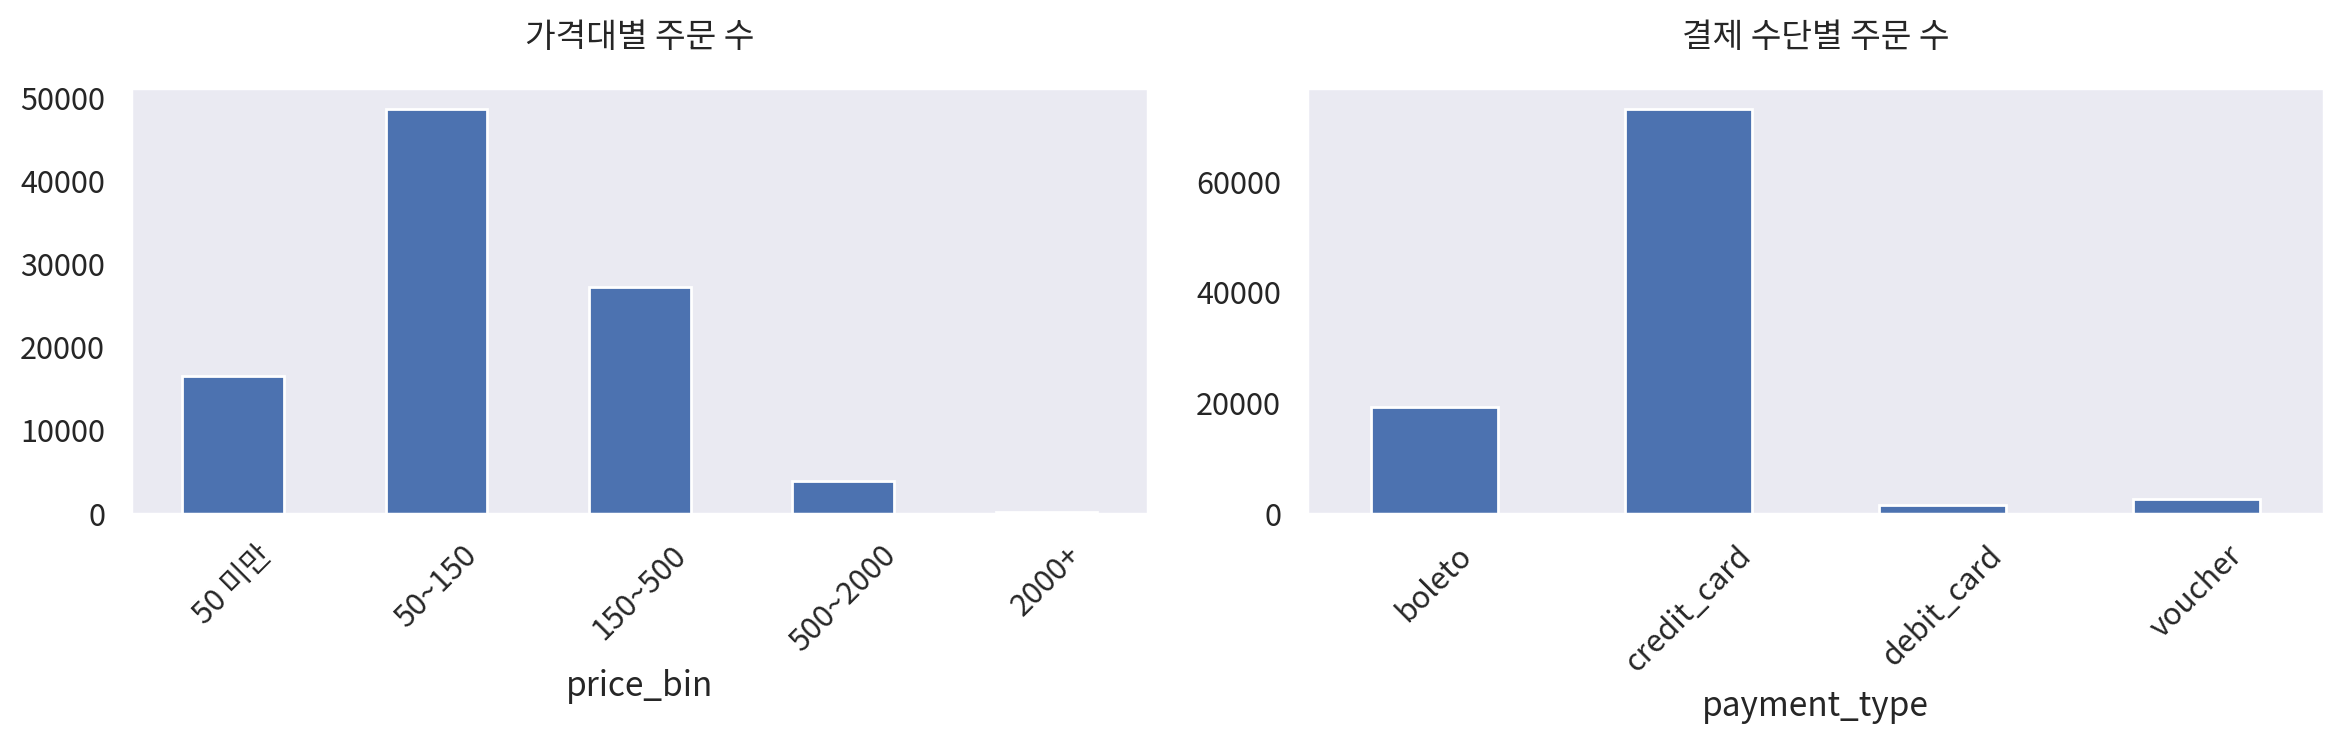

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_price["주문수"].plot(kind="bar", ax=axes[0])
axes[0].set_title("가격대별 주문 수")
axes[0].tick_params(axis="x", rotation=45)
by_payment["주문수"].plot(kind="bar", ax=axes[1])
axes[1].set_title("결제 수단별 주문 수")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()